In [1]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast
import seaborn as sns

from adjustText import adjust_text

#Loading data
dataset = load_dataset ('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])


def clean_list(skill_list):
 if pd.notna(skill_list):
    return ast.literal_eval(skill_list)

df['job_skills']= df['job_skills'].apply(clean_list)

c:\Users\hp\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Filtering for US Data Analyst roles

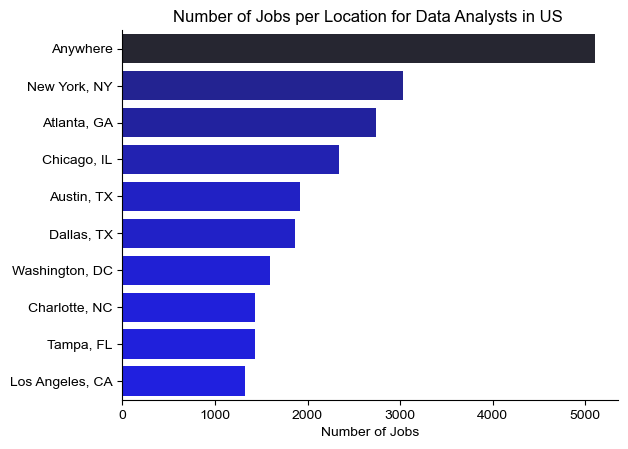

In [2]:
df_DA_USA = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')]

df_plot = df_DA_USA['job_location'].value_counts().head(10).to_frame()

sns.barplot(data=df_plot, x = 'count', y = 'job_location',hue = 'count', palette = 'dark:b_r', legend = False)
sns.set_theme(style = 'ticks')
sns.despine()

plt.title('Number of Jobs per Location for Data Analysts in US ')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()


Opportunities

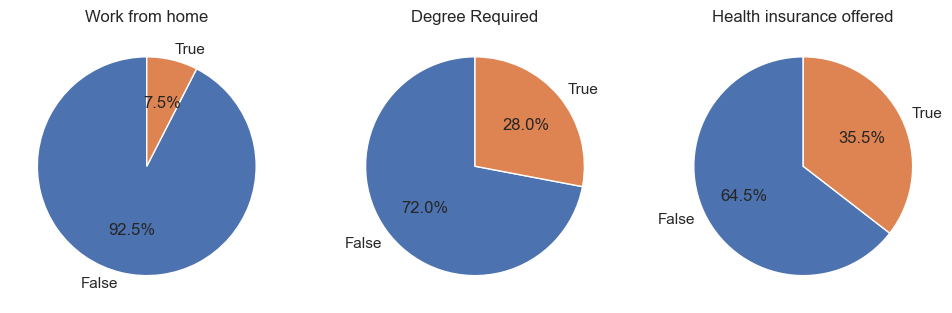

In [3]:
fig , ax = plt.subplots (1,3)
fig.set_size_inches((12,5))

dict_column = {
    'job_work_from_home':'Work from home',
    'job_no_degree_mention':'Degree Required', 
    'job_health_insurance':'Health insurance offered'}

for i, (column,title) in enumerate (dict_column.items()):
  ax[i].pie(df_DA_USA[column].value_counts(),startangle= 90, autopct= '%1.1f%%',labels =['False', 'True'])
  ax[i].set_title(title)

plt.show()

Companies to Explore:

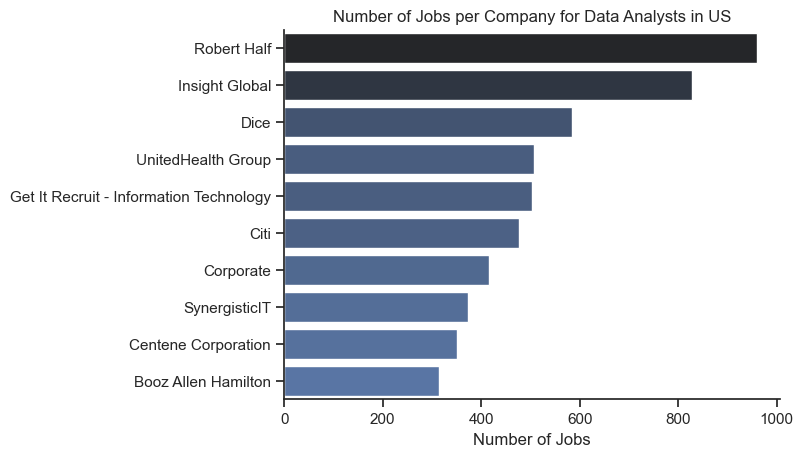

In [4]:
df_plot = df_DA_USA['company_name'].value_counts().head(10).to_frame()

sns.barplot(data=df_plot, x = 'count', y = 'company_name',hue = 'count', palette = 'dark:b_r', legend = False)
sns.set_theme(style = 'ticks')
sns.despine()

plt.title('Number of Jobs per Company for Data Analysts in US')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

Roles to Explore:

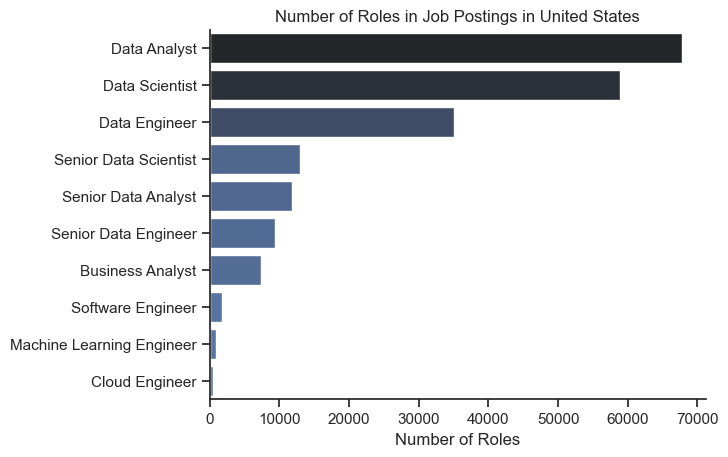

In [5]:
df_DA_US = df[df['job_country'] == 'United States']

df_DA_USA_jobs =  df_DA_US['job_title_short'].value_counts().head(10).to_frame()

sns.barplot(data= df_DA_USA_jobs, x = 'count', y = 'job_title_short',hue = 'count', palette = 'dark:b_r', legend = False)
sns.set_theme(style = 'ticks')
sns.despine()

plt.title('Number of Roles in Job Postings in United States')
plt.xlabel('Number of Roles')
plt.ylabel('')
plt.show()


